In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [28]:
import pandas as pd
df = pd.read_hdf("METR-LA.h5")
df.to_csv("metr_la.csv")

df = pd.read_csv("metr_la.csv")

In [29]:
df.head()
print("Info", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34272 entries, 0 to 34271
Columns: 208 entries, Unnamed: 0 to 769373
dtypes: float64(207), object(1)
memory usage: 54.4+ MB
Info None


In [30]:
print("Shape", df.shape)
print("Describe", df.describe())

Shape (34272, 208)
Describe              773869        767541        767542        717447        717446  \
count  34272.000000  34272.000000  34272.000000  34272.000000  34272.000000   
mean      54.631359     60.452789     60.726120     49.524287     46.079798   
std       22.619199     15.970239     18.313353     15.843261     19.350345   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%       60.364583     63.000000     65.444444     50.333333     34.666667   
50%       64.888889     65.000000     67.375000     53.875000     46.000000   
75%       66.875000     66.375000     68.444444     58.125000     64.500000   
max       70.000000     70.000000     70.000000     70.000000     70.000000   

             717445        773062        767620        737529        717816  \
count  34272.000000  34272.000000  34272.000000  34272.000000  34272.000000   
mean      50.952003     54.471684     57.255095     56.068044     52.871841   
std       16.681760    

In [31]:
# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Handle missing values
df = df.fillna(0)

time_index = pd.date_range(start="2020-01-01", periods=len(df), freq="5min")
df.index = time_index

df.head()

,Unnamed: 0,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2020-01-01 00:00:00,0.0,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2020-01-01 00:05:00,0.0,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2020-01-01 00:10:00,0.0,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2020-01-01 00:15:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2020-01-01 00:20:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [32]:
time_index = pd.date_range(start="2020-01-01", periods=len(df), freq="5min")

df.index = time_index

df.head()

,Unnamed: 0,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2020-01-01 00:00:00,0.0,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2020-01-01 00:05:00,0.0,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2020-01-01 00:10:00,0.0,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2020-01-01 00:15:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2020-01-01 00:20:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [33]:
df_density = 1 / df
df_density = df_density.replace([np.inf], 0)

df_density.head()

,Unnamed: 0,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2020-01-01 00:00:00,0.0,0.015534,0.014787,0.014898,0.016260,0.014953,0.014545,0.015355,0.014898,0.016771,...,0.021918,0.015267,0.015504,0.015054,0.014953,0.016842,0.014493,0.016878,0.014493,0.016162
2020-01-01 00:05:00,0.0,0.015957,0.014587,0.015280,0.016014,0.015517,0.014682,0.015385,0.015385,0.017408,...,0.019737,0.014311,0.015000,0.017078,0.016129,0.016364,0.015517,0.017893,0.014610,0.015905
2020-01-01 00:10:00,0.0,0.015625,0.015686,0.016667,0.016949,0.015038,0.015094,0.015504,0.015564,0.015656,...,0.022663,0.014493,0.017699,0.016878,0.014679,0.016000,0.015238,0.016293,0.014315,0.016129
2020-01-01 00:15:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-01 00:20:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [34]:
df_density['hour'] = df_density.index.hour
df_density['day'] = df_density.index.dayofweek

In [35]:
df_sim = df_density.copy()

# Congestion scaling
df_sim.iloc[:, :-2] = df_sim.iloc[:, :-2] * np.random.uniform(1.2, 1.8)

# Peak hour effect
peak_factor = (
    np.sin((2*np.pi*(df_sim['hour']-8)/24)) +
    np.sin((2*np.pi*(df_sim['hour']-18)/24))
)
df_sim.iloc[:, :-2] = df_sim.iloc[:, :-2].multiply(1 + 0.7*peak_factor, axis=0)

# Random spikes
mask = np.random.rand(len(df_sim)) < 0.1
df_sim.loc[mask, df_sim.columns[:-2]] *= np.random.uniform(1.5, 3)

# Noise
noise = np.random.normal(0, 0.05, df_sim.iloc[:, :-2].shape)
df_sim.iloc[:, :-2] = df_sim.iloc[:, :-2] * (1 + noise)

df_sim.head()

,Unnamed: 0,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,774204,769806,717590,717592,717595,772168,718141,769373,hour,day
2020-01-01 00:00:00,0.0,0.058934,0.057534,0.057288,0.063463,0.063200,0.051695,0.056195,0.056146,0.062916,...,0.051872,0.061356,0.055625,0.060221,0.052418,0.058875,0.057883,0.062061,0,2
2020-01-01 00:05:00,0.0,0.026223,0.023748,0.023983,0.024506,0.022037,0.021141,0.023085,0.023685,0.026172,...,0.022116,0.026698,0.025352,0.027286,0.022994,0.026410,0.024685,0.025677,0,2
2020-01-01 00:10:00,0.0,0.022351,0.024963,0.025862,0.022626,0.023448,0.024175,0.025208,0.022130,0.023606,...,0.024713,0.026523,0.023782,0.025458,0.021949,0.025284,0.021877,0.027404,0,2
2020-01-01 00:15:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,2
2020-01-01 00:20:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,2


In [36]:
df_reduced = pd.DataFrame()

df_reduced['avg_density'] = df_sim.iloc[:, :-2].mean(axis=1)
df_reduced['hour'] = df_sim['hour']
df_reduced['day'] = df_sim['day']

df_reduced.head()

,avg_density,hour,day
2020-01-01 00:00:00,0.058853,0,2
2020-01-01 00:05:00,0.024322,0,2
2020-01-01 00:10:00,0.024542,0,2
2020-01-01 00:15:00,0.000000,0,2
2020-01-01 00:20:00,0.000000,0,2


In [78]:
# 🔥 NEW FEATURES (ADD HERE)
df_reduced['prev2_density'] = df_reduced['avg_density'].shift(2)
df_reduced['rolling_mean_5'] = df_reduced['avg_density'].rolling(5).mean()

# Target variable
df_reduced['target'] = df_reduced['avg_density'].shift(-1)

# Drop NaN values
df_reduced = df_reduced.dropna()

df_reduced.head()

,avg_density,hour,day,prev_density,rolling_mean,target,prev2_density,rolling_mean_5
2020-01-01 00:50:00,0.025286,0,2,0.060709,0.037083,0.025133,0.025253,0.032252
2020-01-01 00:55:00,0.025133,0,2,0.025286,0.037043,0.023334,0.060709,0.032271
2020-01-01 01:00:00,0.023334,1,2,0.025133,0.024585,0.023111,0.025286,0.031943
2020-01-01 01:05:00,0.023111,1,2,0.023334,0.023859,0.023298,0.025133,0.031515
2020-01-01 01:10:00,0.023298,1,2,0.023111,0.023248,0.023512,0.023334,0.024032


In [94]:
# 🧩 CELL 9 (UPDATED)

X = df_reduced[
    ['avg_density', 'prev_density', 'prev2_density',
     'rolling_mean', 'rolling_mean_5', 'hour', 'day']
]

y = df_reduced['target']

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [95]:
model = RandomForestRegressor(
    n_estimators=40,     # balanced
    max_depth=12,        # reduce depth
    min_samples_split=5, # prevent overfitting
    min_samples_leaf=2,  # smoother trees
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=40, n_jobs=-1, random_state=42)

In [96]:
y_pred = model.predict(X_test)

In [97]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.00015849518929828232
R2 Score: 0.5728974143382042


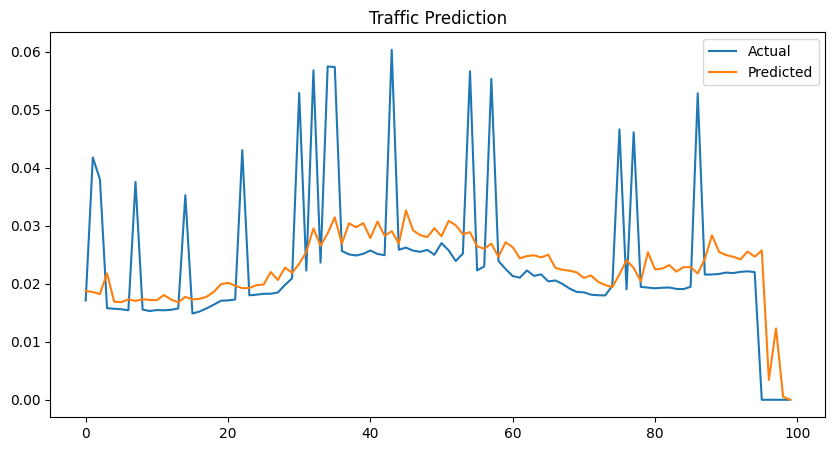

In [98]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Traffic Prediction")
plt.show()

In [99]:
def allocate_signal(densities, total_time=120):
    total_density = sum(densities)
    return [(d / total_density) * total_time for d in densities]

In [100]:
densities = [50, 100, 30, 20]

static = [30, 30, 30, 30]
dynamic = allocate_signal(densities)

print("Static Timing:", static)
print("Dynamic Timing:", dynamic)

Static Timing: [30, 30, 30, 30]
Dynamic Timing: [30.0, 60.0, 18.0, 12.0]


In [101]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

print("TRAIN MSE:", mean_squared_error(y_train, y_train_pred))
print("TEST MSE:", mean_squared_error(y_test, y_test_pred))

print("TRAIN R2:", r2_score(y_train, y_train_pred))
print("TEST R2:", r2_score(y_test, y_test_pred))

TRAIN MSE: 0.00010674154638521352
TEST MSE: 0.00015849518929828232
TRAIN R2: 0.6525278100738927
TEST R2: 0.5728974143382042


In [102]:
import joblib

joblib.dump(model, "traffic_model.pkl")

['traffic_model.pkl']